In [1]:
import torch
import numpy as np

def average_cosine(vectors):

    # Normalize each vector
    vectors_norm = vectors / vectors.norm(dim=1, keepdim=True)

    # Compute the cosine similarity matrix (dot product of normalized vectors)
    cosine_similarities = vectors_norm @ vectors_norm.T

    # Extract the upper triangle of the matrix, excluding the diagonal
    num_objects = vectors.shape[0]
    i, j = torch.triu_indices(num_objects, num_objects, offset=1)
    cosine_similarities_upper = cosine_similarities[i, j]
    # Calculate the average cosine similarity
    average_cosine = cosine_similarities_upper.mean().item()

    
    return average_cosine


def gen_W(num_objects, dim, target_cosine):
    # Define ranges
    sparsity_range = (0.002, 0.01)
    # Initialize the vectors tensor with random sparsity
    vectors = torch.zeros((num_objects, dim), dtype=torch.float)
    num_ones = torch.randint(int(sparsity_range[0] * dim), int(sparsity_range[1] * dim + 1), (num_objects,))
    for i in range(num_objects):
        ones_indices = torch.randperm(dim)[:num_ones[i]]
        vectors[i, ones_indices] = 1

    cos = average_cosine(vectors)
    if target_cosine==0 and cos!=0:
        vectors = torch.zeros((num_objects, dim), dtype=torch.float)
        num_ones = torch.randint(int(sparsity_range[0] * dim), int(sparsity_range[1] * dim + 1), (num_objects,))
        for i in range(num_objects):
            ones_indices = torch.randperm(dim)[:num_ones[i]]
            vectors[i, ones_indices] = 1

        cos = average_cosine(vectors)
        

    while(cos<target_cosine):
        # Randomly pick a pair of objects i and j
        indices = torch.randperm(num_objects)[:2]
        i, j = indices[0], indices[1]
        vi = vectors[i, :]
        vj = vectors[j, :]

        # Identify dimensions where only one of them has a 1 using XOR
        diff_indices = torch.nonzero(vi.int() ^ vj.int()).flatten()
        if len(diff_indices) > 0:
            # Randomly pick one such dimension
            dim_to_change = diff_indices[torch.randint(len(diff_indices), (1,)).item()]
        else:
            continue

        # Determine which vector has 0 at the chosen dimension
        if vi[dim_to_change] == 0:
            index_to_modify = i
        else:
            index_to_modify = j

        # Set the value of this object at the chosen dimension to 1
        vectors[index_to_modify, dim_to_change] = 1

        # Find a dimension in the same object that currently equals 1
        ones_indices = torch.nonzero(vectors[index_to_modify] == 1).flatten()
        ones_indices = ones_indices[ones_indices != dim_to_change]  # Exclude the modified dimension

        # Randomly pick one such dimension to set to 0
        dim_to_zero = ones_indices[torch.randint(len(ones_indices), (1,)).item()]
        vectors[index_to_modify, dim_to_zero] = 0

        # Compute the average cosine again
        cos = average_cosine(vectors)
#     print(cos)
    return vectors.T



In [2]:
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import torch
import numpy as np
from tqdm.notebook import tqdm

# Set parameters
num_objects = 10
input_dim = num_objects
hidden_dim = 10000
cosine = 0.1
output_dim = 1

# Ground truth ranking
ground_truth_ranking = list(range(num_objects))

# Create all possible pairs and labels
test_pairs = [(i, j) for i in range(num_objects) for j in range(num_objects) if ((i != j) and (i-j!=1) and (j-i!=1))]
test_labels = [1 if ground_truth_ranking.index(i) < ground_truth_ranking.index(j) else -1 for i, j in test_pairs]

train_pairs = [(i, i+1) for i in range(num_objects-1)]
train_labels = [1 for i, j in train_pairs]

# One-hot encode the input
one_hot_vectors = torch.eye(num_objects)

# Split into training and testing datasets


# Initialize results storage
all_accuracies = []
all_accuracies_w = []
all_mean_values = []
delta = 1
# Repeat the experiment

# Initialize weights for both cases
W1 = gen_W(num_objects, hidden_dim, cosine)
P1 = torch.randn(output_dim, hidden_dim) * 0.0001
allcorrect1 = False
# Learning rate
eta = 0.01

# Training parameters
total_iterations = 400

accuracies1 = []

accuracies_w1 = []

mean_v_values = np.zeros((total_iterations, num_objects))

# Training loop
for iteration in range(total_iterations):
    # Randomly pick a sample from the training set
    idx = np.random.randint(0, len(train_pairs))
    (i, j), label = train_pairs[idx], train_labels[idx]

    # Case 1: Training with W1
    s_i1 = W1 @ one_hot_vectors[i]
    s_j1 = W1 @ one_hot_vectors[j]
    v_i1 = P1 @ s_i1
    v_j1 = P1 @ s_j1

    error1 = torch.sign(torch.maximum((label * (v_i1 - v_j1) +delta), torch.tensor(0))*label)

#         break
    e_vec1 = error1 
#         print(e_vec1)

    with torch.no_grad():
        if not allcorrect1:
            P1 += eta * torch.outer(e_vec1, s_j1 - s_i1)


    for i in range(num_objects):
        s1 = W1 @ one_hot_vectors[i]
        v1 = P1 @ s1

        mean_v_values[iteration, i] = v1.mean().item()

    summed_v_values = mean_v_values[iteration, :]
    learned_ranking = sorted(range(num_objects), key=lambda i: summed_v_values[i])
    if learned_ranking == list(ground_truth_ranking):
        if allcorrect1 == False:
            print('ortho:', iteration, len(accuracies_w1))
        allcorrect1 = True




    # Evaluate on the test set
    if iteration % 1 == 0:  # Test every iteration
        correct1 = 0

        for (i_test, j_test), label_test in zip(test_pairs, test_labels):
            # Case 1: Testing with W1
            s_i_test1 = W1 @ one_hot_vectors[i_test]
            s_j_test1 = W1 @ one_hot_vectors[j_test]
            v_i_test1 = P1 @ s_i_test1
            v_j_test1 = P1 @ s_j_test1
            prediction1 = 1 if v_i_test1.mean() < v_j_test1.mean() else -1
            correct1 += (prediction1 == label_test)


        # Calculate accuracies
        accuracy1 = correct1 / len(test_pairs)
        accuracies1.append(accuracy1)
        if error1 != 0:
            accuracies_w1.append(accuracy1)




Repeats:   0%|          | 0/100 [00:00<?, ?it/s]

0
ortho: 145 76
1
ortho: 201 125
2
ortho: 183 95
3
ortho: 356 188
4
ortho: 122 73
5
ortho: 168 91
6
ortho: 159 88
7
ortho: 164 109
8
ortho: 167 123
9
ortho: 221 126
10
ortho: 251 154
11
ortho: 287 143
12
ortho: 197 111
13
ortho: 201 103
14
ortho: 295 168
15
ortho: 225 119
16
ortho: 220 137
17
ortho: 290 148
18
ortho: 170 100
19
ortho: 192 130
20
ortho: 342 164
21
ortho: 230 114
22
ortho: 256 135
23
ortho: 310 141
24
ortho: 312 155
25
ortho: 172 96
26
ortho: 219 133
27
ortho: 199 105
28
ortho: 228 124
29
ortho: 262 149
30
ortho: 312 152
31
ortho: 369 191
32
ortho: 326 167
33
ortho: 208 119
34
ortho: 210 121
35
ortho: 235 127
36
ortho: 169 114
37
ortho: 209 120
38
ortho: 268 173
39
ortho: 187 99
40
ortho: 275 161
41
ortho: 143 85
42
ortho: 156 85
43
ortho: 219 90
44
ortho: 314 150
45
ortho: 214 124
46
ortho: 226 119
47
ortho: 207 97
48
ortho: 165 86
49
ortho: 280 155
50
ortho: 292 147
51
ortho: 359 195
52
ortho: 282 151
53
ortho: 138 86
54
ortho: 221 115
55
ortho: 294 184
56
ortho: 148 9

In [50]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# -----------------------------
# Your functions (verbatim)
# -----------------------------
def average_cosine(vectors):
    vectors_norm = vectors / vectors.norm(dim=1, keepdim=True)
    cosine_similarities = vectors_norm @ vectors_norm.T
    num_objects = vectors.shape[0]
    i, j = torch.triu_indices(num_objects, num_objects, offset=1)
    cosine_similarities_upper = cosine_similarities[i, j]
    return cosine_similarities_upper.mean().item()

def gen_W(num_objects, dim, target_cosine):
    sparsity_range = (0.002, 0.01)
    vectors = torch.zeros((num_objects, dim), dtype=torch.float)
    num_ones = torch.randint(int(sparsity_range[0] * dim), int(sparsity_range[1] * dim + 1), (num_objects,))
    for i in range(num_objects):
        ones_indices = torch.randperm(dim)[:num_ones[i]]
        vectors[i, ones_indices] = 1

    cos = average_cosine(vectors)
    if target_cosine == 0 and cos != 0:
        vectors = torch.zeros((num_objects, dim), dtype=torch.float)
        num_ones = torch.randint(int(sparsity_range[0] * dim), int(sparsity_range[1] * dim + 1), (num_objects,))
        for i in range(num_objects):
            ones_indices = torch.randperm(dim)[:num_ones[i]]
            vectors[i, ones_indices] = 1
        cos = average_cosine(vectors)

    while cos < target_cosine:
        indices = torch.randperm(num_objects)[:2]
        i, j = indices[0], indices[1]
        vi = vectors[i, :]
        vj = vectors[j, :]

        diff_indices = torch.nonzero(vi.int() ^ vj.int()).flatten()
        if len(diff_indices) > 0:
            dim_to_change = diff_indices[torch.randint(len(diff_indices), (1,)).item()]
        else:
            continue

        if vi[dim_to_change] == 0:
            index_to_modify = i
        else:
            index_to_modify = j

        vectors[index_to_modify, dim_to_change] = 1

        ones_indices = torch.nonzero(vectors[index_to_modify] == 1).flatten()
        ones_indices = ones_indices[ones_indices != dim_to_change]
        dim_to_zero = ones_indices[torch.randint(len(ones_indices), (1,)).item()]
        vectors[index_to_modify, dim_to_zero] = 0

        cos = average_cosine(vectors)

    return vectors.T  # (dim, num_objects)

# -----------------------------
# Fast runner using pre-generated W and P0
# -----------------------------
def run_one_fast(train_pairs, W, P0, delta, eta=0.01, total_iterations=400):
    # W: (hidden_dim, num_objects). Column i is s_i.
    P = P0.clone()
    num_objects = W.shape[1]

    for _ in range(total_iterations):
        i, j = train_pairs[np.random.randint(0, len(train_pairs))]

        s_i = W[:, i]
        s_j = W[:, j]
        v_i = (P @ s_i).squeeze()
        v_j = (P @ s_j).squeeze()

        if (v_i - v_j + delta) > 0:
            P += eta * (s_j - s_i).unsqueeze(0)

        # ranking check: v_all = P @ W gives (1, num_objects)
        v_all = (P @ W).squeeze(0)
        if torch.argsort(v_all).tolist() == list(range(num_objects)):
#             print(_)
            return 1

    return 0

# -----------------------------
# Grid + plot (reuse W and P0 across deltas per run)
# -----------------------------
deltas = [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1, 2, 5]
hidden_dims = [1000, 10000]
cosines = [0.1, 0.0]
runs = 100

num_objects = 10
train_pairs = [(i, i + 1) for i in range(num_objects - 1)]

base_seed = 20260203
results = {}

for hd in tqdm(hidden_dims,desc='hidden'):
    for cos in tqdm(cosines,desc='cos'):
        # pre-generate 10 W and 10 P0 for this condition
        Ws = []
        Ps = []
        for r in range(runs):
            seed = base_seed + 100000 * (hd == 10000) + 1000 * int(round(cos * 10)) + r
            torch.manual_seed(seed)
            np.random.seed(seed)
            W = gen_W(num_objects, hd, cos)  # (hd, num_objects)
            P0 = torch.randn(1, hd) * 1e-4
            Ws.append(W)
            Ps.append(P0)

        rates = []
        for d in deltas:
            succ = 0
            for r in range(runs):
                # keep delta as the only swept parameter; still random due to sampling pairs
                succ += run_one_fast(train_pairs, Ws[r], Ps[r], delta=d, eta=0.01, total_iterations=1000)
            rates.append(succ / runs)
        results[(hd, cos)] = rates





hidden:   0%|          | 0/2 [00:00<?, ?it/s]

cos:   0%|          | 0/2 [00:00<?, ?it/s]

cos:   0%|          | 0/2 [00:00<?, ?it/s]

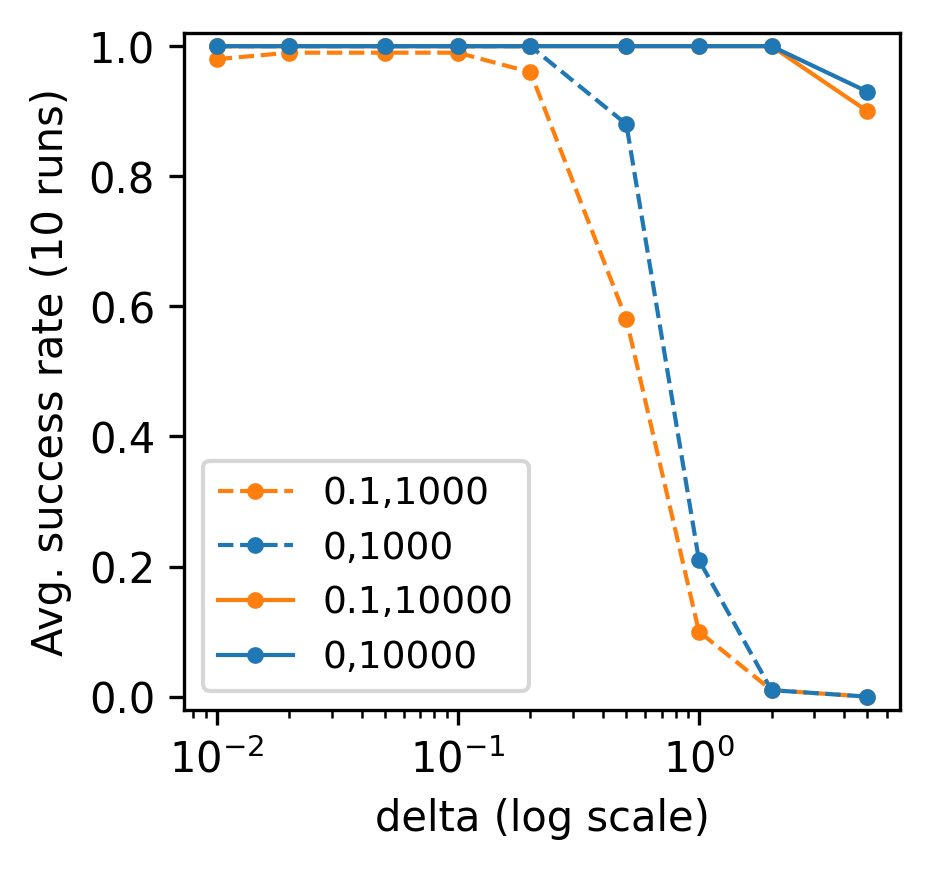

In [51]:
plt.figure(figsize=(3.2,3),dpi=300)
for hd in hidden_dims:
    for cos in cosines:
        color = 'tab:orange' if abs(cos - 0.1) < 1e-12 else 'tab:blue'
        linestyle = '--' if hd == 1000 else '-'
        plt.plot(deltas, results[(hd, cos)], marker='.', lw=1,linestyle=linestyle, color=color,
                 label=f"{cos:g},{hd}",alpha=1)

plt.xscale('log')
plt.ylim(-0.02, 1.02)
plt.xlabel("delta (log scale)")
plt.ylabel("Avg. success rate (10 runs)")
# plt.title("Parameter sensitivity of delta")
# plt.grid(True, which='both', alpha=0.3)
plt.legend(frameon=True, fontsize=9,loc='lower left')
plt.tight_layout()